In [1]:
import pandas as pd
from sklearn.mixture import GaussianMixture
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
import numpy as np
from hmmlearn.hmm import GaussianHMM
import hdbscan
import plotly.graph_objects as go



In [2]:
with open('../../data/nifty_ts2vec_embeddings.pkl', 'rb') as f:
    df = pickle.load(f)

In [3]:
df = df.loc["2020-04-01":]

In [4]:
embeddings = df.drop("Close", axis=1)
embeddings

,0,1,2,3,4,5,6,7,8,9,...,54,55,56,57,58,59,60,61,62,63
Date,,,,,,,,,,,,,,,,,,,,,
2020-04-01,0.000000,0.025101,0.000000,0.016454,0.073053,0.104434,0.050011,0.031171,0.053078,0.000000,...,0.000000,0.062778,0.000000,0.0,0.040466,0.001161,0.002041,0.019211,0.000525,0.000000
2020-04-03,0.000000,0.024347,0.000000,0.023870,0.078691,0.101145,0.051939,0.031012,0.046387,0.000000,...,0.000000,0.062996,0.000000,0.0,0.031342,0.000886,0.001449,0.014427,0.001365,0.000000
2020-04-07,0.000000,0.023446,0.000000,0.032438,0.085492,0.095963,0.051772,0.030542,0.040963,0.000000,...,0.000000,0.064622,0.000000,0.0,0.022094,0.000942,0.000951,0.009305,0.002339,0.000000
2020-04-08,0.000000,0.022914,0.000000,0.040841,0.091619,0.089819,0.052776,0.030293,0.037783,0.000000,...,0.000053,0.067072,0.000000,0.0,0.013530,0.001301,0.000000,0.005141,0.003940,0.000000
2020-04-09,0.000000,0.021467,0.000000,0.048681,0.096341,0.083919,0.051978,0.030182,0.036498,0.000000,...,0.002001,0.069181,0.000000,0.0,0.008670,0.003267,0.000000,0.001642,0.007053,0.000003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-09-15,0.005040,0.038136,0.046456,0.000000,0.000000,0.036919,0.187390,0.053806,0.072642,0.018291,...,0.000000,0.042811,0.007385,0.0,0.000000,0.000000,0.000000,0.043218,0.119463,0.120130
2025-09-16,0.003514,0.037726,0.049619,0.000000,0.000000,0.040501,0.178778,0.045467,0.074874,0.017573,...,0.000000,0.043482,0.006250,0.0,0.000000,0.000000,0.000000,0.041971,0.110495,0.116167
2025-09-17,0.002419,0.035861,0.052268,0.000000,0.000000,0.045409,0.170200,0.039427,0.076267,0.017829,...,0.000000,0.045017,0.004854,0.0,0.000000,0.000000,0.000000,0.042737,0.103700,0.111448


In [6]:
30*0.6

18.0

In [7]:
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=6,
    metric="euclidean",
    cluster_selection_method="leaf",
    cluster_selection_epsilon = 0,   
    allow_single_cluster=False,
    prediction_data=True
)
labels = clusterer.fit_predict(embeddings)

In [8]:
df["HDBSCAN_Labels"] = labels

In [9]:
df["HDBSCAN_Labels"].value_counts(normalize=True)

HDBSCAN_Labels
-1     0.271787
 7     0.083456
 12    0.068685
 9     0.061300
 5     0.059823
 1     0.053914
 4     0.053914
 0     0.051699
 8     0.042836
 10    0.042097
 11    0.039143
 14    0.030281
 3     0.028065
 2     0.025111
 6     0.024372
 16    0.023634
 13    0.021418
 15    0.018464
Name: proportion, dtype: float64

In [10]:
df["HDBSCAN_Labels"].value_counts(normalize=True).head().to_clipboard()

In [11]:
df["HDBSCAN_Labels"].nunique() #51

18

In [12]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HDBSCAN_Labels"].dropna().unique()):
    mask = df["HDBSCAN_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

In [13]:
# plt.figure(figsize=(25,6))

# for c in df['HDBSCAN_Labels'].dropna().unique():
#     mask = df['HDBSCAN_Labels'] == c
#     plt.scatter(df.index[mask], df['Close'][mask], label=f"Regime {c}", s=10)
# plt.plot(df.index, df['Close'], color='black', linewidth=0.5, alpha=0.6)
# plt.title("Nifty 50 Regimes (Clustering)")
# plt.legend()
# plt.show()

In [14]:
hdb_labels = df["HDBSCAN_Labels"].values

In [15]:
from sklearn.metrics import pairwise_distances_argmin

# Ensure we operate on numpy arrays (pairwise_distances_argmin expects array-like)
X = embeddings.to_numpy() if hasattr(embeddings, "to_numpy") else np.asarray(embeddings)
labels = np.asarray(hdb_labels).copy()

# centroids from non-noise clusters
clusters = np.unique(labels[labels >= 0])

# If everything is noise (or there are no points), we can't reassign
if clusters.size == 0:
    print("No non-noise clusters found; leaving labels unchanged.")
else:
    centroids = np.vstack([X[labels == k].mean(axis=0) for k in clusters])

    # reassign noise (if any) to nearest centroid
    noise_idx = np.where(labels == -1)[0]
    if noise_idx.size == 0:
        print("No noise points to reassign.")
    else:
        nearest = pairwise_distances_argmin(X[noise_idx], centroids)
        labels[noise_idx] = clusters[nearest]

In [16]:
np.mean(labels == -1)

0.0

In [17]:
len(centroids)

17

In [18]:
from sklearn.cluster import AgglomerativeClustering

K0 = 15  # start here

agg = AgglomerativeClustering(
    n_clusters=K0,
    linkage="ward"
)

proto_labels = agg.fit_predict(centroids)

In [19]:
proto_labels

array([12, 13, 11, 14,  8,  0,  5,  0,  6,  1,  1,  2,  7, 10,  9,  3,  4])

In [20]:
proto_state = np.zeros_like(labels)
cluster_ids = np.unique(labels)

for cid, p in zip(cluster_ids, proto_labels):
    proto_state[labels == cid] = p

In [21]:
np.unique(proto_state)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [22]:
def init_from_micro_regimes(X, labels, min_points=20):
    states = np.unique(labels)
    means, covs = [], []

    for k in states:
        pts = X[labels == k]
        if len(pts) < min_points:
            continue
        means.append(pts.mean(axis=0))
        covs.append(
            np.cov(pts.T) + 1e-6 * np.eye(X.shape[1])
        )

    return np.array(means), np.array(covs)


def full_to_diag_cov(covs):
    """
    covs: (K, D, D)
    returns: (K, D)
    """
    return np.array([
        np.diag(cov) for cov in covs
    ])


def init_from_proto_states_diag(X, proto_state, min_points=50):
    states = np.unique(proto_state)
    means, diag_covs = [], []

    for k in states:
        pts = X[proto_state == k]
        if len(pts) < min_points:
            continue

        mu = pts.mean(axis=0)
        cov = np.cov(pts.T)

        # strong regularization for stability
        cov += 1e-3 * np.eye(X.shape[1])

        means.append(mu)
        diag_covs.append(np.diag(cov))

    return np.array(means), np.array(diag_covs)

In [23]:
init_means, init_covs = init_from_proto_states_diag(
    embeddings, proto_state
)

K = len(init_means)
print("HMM init states:", K)

HMM init states: 11


In [24]:
from hmmlearn.hmm import GaussianHMM

def sticky_transition(K, kappa=70, base=1.0):
    A = np.full((K, K), base)
    np.fill_diagonal(A, base + kappa)
    return A / A.sum(axis=1, keepdims=True)


model = GaussianHMM(
    n_components=K,
    covariance_type="diag",   
    n_iter=1500,
    tol=1e-3,
    init_params=""
)

model.startprob_ = np.ones(K) / K
model.transmat_ = sticky_transition(K)
model.means_ = init_means
model.covars_ = init_covs

model.fit(embeddings)

Model is not converging.  Current: 201930.98292498826 is not greater than 201931.01356618988. Delta is -0.030641201621619985


,n_components,11
,covariance_type,'diag'
,min_covar,0.001
,startprob_prior,1.0
,transmat_prior,1.0
,means_prior,0
,means_weight,0
,covars_prior,0.01
,covars_weight,1
,algorithm,'viterbi'
,random_state,None


In [25]:
# save the model
with open('../../models/nifty_hmm_model.pkl', 'wb') as f:
    pickle.dump(model, f)

In [5]:
# load the model
with open('../../models/nifty_hmm_model.pkl', 'rb') as f:
    model = pickle.load(f)

In [6]:
post = model.predict_proba(embeddings)
state_mass = post.mean(axis=0)

print("Effective states:",
      np.sum(state_mass > 0.01))

Effective states: 11


In [7]:
post.shape

(1354, 11)

In [8]:
len(state_mass)

11

In [9]:
state_mass

array([0.16655634, 0.17203287, 0.07332644, 0.05275193, 0.07149354,
       0.10133884, 0.08152857, 0.0916592 , 0.05540053, 0.09329329,
       0.04061845])

In [10]:
keep = state_mass > 0.03
posteriors = post[:, keep]

In [11]:
posteriors.shape

(1354, 11)

In [12]:
viterbi = model.predict(embeddings)
np.mean(viterbi[1:] == viterbi[:-1])

0.9852180339985218

In [13]:
len(viterbi)

1354

In [14]:
df["HMM_Labels"] = viterbi

In [15]:
df["HMM_Labels"].value_counts()

HMM_Labels
1     233
0     226
5     137
9     126
7     124
6     110
2     100
4      97
8      75
3      71
10     55
Name: count, dtype: int64

In [16]:
fig = go.Figure()

# Scatter per regime/cluster
for c in sorted(df["HMM_Labels"].dropna().unique()):
    mask = df["HMM_Labels"] == c
    fig.add_trace(
        go.Scatter(
            x=df.index[mask],
            y=df.loc[mask, "Close"],
            mode="markers",
            name=f"Regime {c}",
            marker=dict(size=6),
        )
    )

# Underlay full close series
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
    )
)

fig.update_layout(
    title="Nifty 50 Regimes (Clustering)",
    # width=1400,
    height=820,
    legend_title_text="Regime",
    xaxis_title="Date",
    yaxis_title="Close",
    template="plotly_white",
)

fig.show()

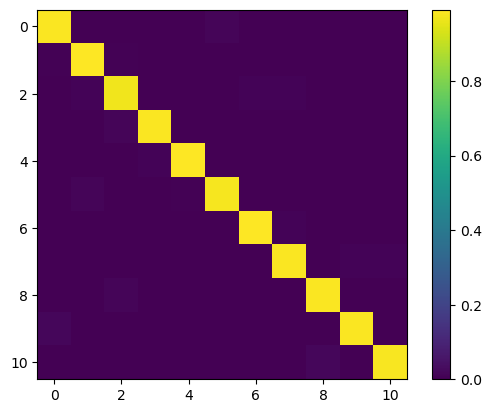

In [17]:
plt.imshow(model.transmat_, cmap="viridis")
plt.colorbar()

In [18]:
def compute_state_signatures(
    states,
    returns,
    volatility,
    price,
    lookback_weight=None
):
    """
    returns DataFrame of shape (K, features)
    """

    K = int(states.max()) + 1
    sig = []
    print("Computing signatures for", K, "states")

    T = len(states)
    weights = (
        np.exp(-np.arange(T)[::-1] / lookback_weight)
        if lookback_weight is not None
        else np.ones(T)
    )

    for k in range(K):
        print(f"State {k}: ", end="")
        idx = states == k
        if idx.sum() < 30:
            print("Ignoring ", idx)
            continue

        w = weights[idx]

        sig.append({
            "state": k,
            "freq": idx.mean(),
            "mean_return": np.average(returns[idx], weights=w),
            "volatility": np.average(volatility[idx], weights=w),
            "trend": np.polyfit(
                np.arange(idx.sum()),
                price[idx],
                1
            )[0],
            "drawdown": np.min(
                price[idx] / np.maximum.accumulate(price[idx]) - 1
            ),
        })

    return pd.DataFrame(sig).set_index("state")

In [19]:
# X_emb        # ts2vec embeddings (T, D)
# returns      # daily log returns (T,)
# volatility   # rolling vol (T,)
# price        # index price (T,)
# states       # HMM state sequence (T,)
# posteriors   # HMM posteriors (T, K)

returns = np.log(df["Close"] / df["Close"].shift(1)).fillna(0).values
volatility = df["Close"].rolling(20).std().bfill().values
price = df["Close"].values
states = viterbi
state_df = compute_state_signatures(
    states, returns, volatility, price, lookback_weight=100
)


Computing signatures for 11 states
State 0: State 1: State 2: State 3: State 4: State 5: State 6: State 7: State 8: State 9: State 10: 

In [20]:

state_df.sort_values("freq", ascending=False)

,freq,mean_return,volatility,trend,drawdown
state,,,,,
1,0.172083,-0.000142,273.048818,36.482012,-0.108431
0,0.166913,0.002704,446.248589,66.486977,-0.082100
5,0.101182,0.000053,234.778716,103.389299,-0.064221
9,0.093058,-0.001243,387.729042,82.827571,-0.133545
7,0.091581,0.000897,218.252955,44.032421,-0.100820
6,0.081241,0.001240,302.159638,14.859218,-0.066119
2,0.073855,-0.001423,401.530753,112.981402,-0.069295
4,0.071640,0.001438,306.812001,24.659687,-0.068974
8,0.055391,0.001395,343.753628,30.773222,-0.059294


In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

features = [
    "mean_return",
    "volatility",
    "trend",
    "drawdown",
]

X_state = StandardScaler().fit_transform(state_df[features])

clusterer = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

state_df["macro_regime"] = clusterer.fit_predict(X_state)

In [22]:
state_to_macro = state_df["macro_regime"].to_dict()
macro_states = np.array([state_to_macro[s] for s in states])

In [23]:
macro_summary = (
    state_df
    .groupby("macro_regime")
    .agg({
        "mean_return": "mean",
        "volatility": "mean",
        "trend": "mean",
        "drawdown": "mean",
    })
)

In [24]:
labels = {}

ret_rank = macro_summary["mean_return"].rank()
vol_rank = macro_summary["volatility"].rank()
dd_rank  = macro_summary["drawdown"].rank()

for k in macro_summary.index:
    if ret_rank[k] == ret_rank.max() and vol_rank[k] <= 3:
        labels[k] = "Strong Bull"

    elif ret_rank[k] >= 4:
        labels[k] = "Bull"

    elif ret_rank[k] <= 2 and dd_rank[k] <= 2:
        labels[k] = "Bear"

    elif vol_rank[k] == vol_rank.max():
        labels[k] = "High Volatility"

    else:
        labels[k] = "Sideways / Transition"

In [25]:
macro_summary["label"] = macro_summary.index.map(labels)

In [26]:
macro_summary

,mean_return,volatility,trend,drawdown,label
macro_regime,,,,,
0,0.001089,272.750549,20.432029,-0.053641,Bull
1,-0.000685,318.154735,108.185350,-0.066758,Sideways / Transition
2,0.002704,446.248589,66.486977,-0.082100,Bull
3,0.000377,245.650886,40.257216,-0.104625,Sideways / Transition
4,-0.001243,387.729042,82.827571,-0.133545,Bear


In [27]:
bull_strength = {}

for k, row in macro_summary.iterrows():
    if row["label"] == "Strong Bull":
        bull_strength[k] = 1.0
    elif row["label"] == "Bull":
        bull_strength[k] = 0.75
    elif row["label"] == "Sideways / Transition":
        bull_strength[k] = 0.55
    elif row["label"] == "High Volatility":
        bull_strength[k] = 0.2
    else:  # Bear
        bull_strength[k] = 0.0

In [28]:
def rolling_percentile(x, window=252):
    out = np.full_like(x, np.nan)
    for i in range(window, len(x)):
        out[i] = (
            np.sum(x[i-window:i] <= x[i]) / window
        )
    return out

In [29]:
state_to_macro

{0: 2, 1: 3, 2: 1, 3: 0, 4: 0, 5: 1, 6: 0, 7: 3, 8: 0, 9: 4, 10: 0}

In [30]:
state_bull_strength = {
    s: bull_strength[state_to_macro[s]]
    for s in state_to_macro
}
state_bull_strength

{0: 0.75,
 1: 0.55,
 2: 0.55,
 3: 0.75,
 4: 0.75,
 5: 0.55,
 6: 0.75,
 7: 0.55,
 8: 0.75,
 9: 0.0,
 10: 0.75}

In [31]:
def bull_confidence_from_posteriors(posteriors, state_bull_strength):
    """
    posteriors: (T, K)
    returns: (T,) bull confidence in [0, 1]
    """
    weights = np.array([
        state_bull_strength[k] for k in range(posteriors.shape[1])
    ])
    return posteriors @ weights

In [32]:
posteriors

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 1.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 1.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 1.00000000e+000, 0.00000000e+000],
       ...,
       [0.00000000e+000, 1.00000000e+000, 1.78859349e-043, ...,
        0.00000000e+000, 6.89592663e-311, 0.00000000e+000],
       [0.00000000e+000, 1.00000000e+000, 1.08445130e-042, ...,
        0.00000000e+000, 1.40855630e-266, 0.00000000e+000],
       [4.26733389e-304, 1.00000000e+000, 6.69773985e-041, ...,
        4.67593609e-319, 8.58804212e-225, 3.34541865e-260]])

In [33]:
bull_conf = bull_confidence_from_posteriors(
    posteriors,
    state_bull_strength
)
bull_conf

array([0.00000000e+000, 2.31744118e-285, 9.55736500e-290, ...,
       5.50000000e-001, 5.50000000e-001, 5.50000000e-001])

In [34]:
# plot bull confidence over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf,
        mode="lines",
        name="Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [35]:
def smooth_series(x, half_life=20):
    alpha = 1 - np.exp(np.log(0.5) / half_life)
    y = np.zeros_like(x)
    y[0] = x[0]
    for t in range(1, len(x)):
        y[t] = alpha * x[t] + (1 - alpha) * y[t-1]
    return y

bull_conf_smooth = smooth_series(bull_conf, half_life=20)
bull_conf_rel = rolling_percentile(bull_conf_smooth, 252)

In [36]:
# plot bull_conf_smooth over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_smooth,
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_conf_rel,
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Smoothed Bull Confidence Over Time",
    xaxis_title="Date",
    yaxis_title="Smoothed Bull Confidence",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [37]:
bull_momentum = bull_conf_smooth - smooth_series(
    bull_conf_smooth, half_life=60
)

In [38]:
# plot bull momentum over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=bull_momentum,
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=df.index,
        y=df["Close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum Over Time",
    xaxis_title="Date",
    yaxis_title="Bull Momentum",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()

In [39]:
from scipy.stats import multivariate_normal

def hmm_filter_step(x_t, prev_gamma, model):
    K = model.n_components

    # emission likelihoods
    lik = np.zeros(K)
    for k in range(K):
        lik[k] = multivariate_normal.pdf(
            x_t,
            mean=model.means_[k],
            cov=model.covars_[k]
        )

    # predict
    pred = prev_gamma @ model.transmat_

    # update
    gamma = pred * lik
    gamma /= gamma.sum()

    return gamma

In [40]:
gamma_t = posteriors[-1]
gamma_t

array([4.26733389e-304, 1.00000000e+000, 6.69773985e-041, 0.00000000e+000,
       0.00000000e+000, 1.60362429e-314, 2.10241497e-132, 2.67395557e-187,
       4.67593609e-319, 8.58804212e-225, 3.34541865e-260])

In [45]:
# infer_ts2vec_embeddings
with open('../../data/infer_ts2vec_embeddings.pkl', 'rb') as f:
    infer_embeddings = pickle.load(f)

In [56]:
i_close = infer_embeddings["Close"]
infer_emb = infer_embeddings.drop("Close", axis=1).values
infer_emb

array([[0.        , 0.02974753, 0.05988763, ..., 0.0512322 , 0.08420741,
        0.09935395],
       [0.        , 0.02836407, 0.06152033, ..., 0.05149364, 0.07737555,
        0.09332695],
       [0.        , 0.02654998, 0.061947  , ..., 0.0511014 , 0.06851815,
        0.0882587 ],
       ...,
       [0.        , 0.16248207, 0.01634628, ..., 0.03115277, 0.0625428 ,
        0.        ],
       [0.        , 0.1685627 , 0.02328803, ..., 0.03192077, 0.06914065,
        0.        ],
       [0.        , 0.17629269, 0.02961083, ..., 0.03225477, 0.07154922,
        0.00144713]], dtype=float32)

In [54]:
infer_embeddings

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,Close
Date,,,,,,,,,,,,,,,,,,,,,
2025-09-22,0.0,0.029748,0.059888,0.000647,0.0,0.058480,0.164221,0.033598,0.078885,0.025395,...,0.045337,0.000649,0.0,0.002006,0.000000,0.0,0.051232,0.084207,0.099354,25202.349609
2025-09-23,0.0,0.028364,0.061520,0.001627,0.0,0.061448,0.164996,0.034486,0.079725,0.029861,...,0.042712,0.000143,0.0,0.003235,0.000000,0.0,0.051494,0.077376,0.093327,25169.500000
2025-09-24,0.0,0.026550,0.061947,0.002922,0.0,0.062570,0.162276,0.034639,0.081293,0.034162,...,0.042411,0.000105,0.0,0.004253,0.000000,0.0,0.051101,0.068518,0.088259,25056.900391
2025-09-25,0.0,0.023837,0.061498,0.004292,0.0,0.060381,0.160451,0.035796,0.082584,0.038182,...,0.044660,0.000603,0.0,0.007293,0.000000,0.0,0.048084,0.059472,0.083237,24890.849609
2025-09-26,0.0,0.021092,0.058885,0.006007,0.0,0.058932,0.163815,0.036404,0.083164,0.041136,...,0.042865,0.002708,0.0,0.009461,0.000000,0.0,0.043547,0.056614,0.078620,24654.699219
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-13,0.0,0.154281,0.008402,0.044421,0.0,0.052127,0.069970,0.042097,0.008249,0.000567,...,0.016039,0.000000,0.0,0.108517,0.009591,0.0,0.029182,0.051806,0.000000,25471.099609
2026-02-16,0.0,0.158853,0.010573,0.043895,0.0,0.049044,0.068458,0.041026,0.008487,0.000000,...,0.015723,0.000000,0.0,0.111690,0.012029,0.0,0.030499,0.056426,0.000000,25682.750000
2026-02-17,0.0,0.162482,0.016346,0.044965,0.0,0.046490,0.067333,0.042729,0.009003,0.000000,...,0.016110,0.000000,0.0,0.113847,0.013575,0.0,0.031153,0.062543,0.000000,25725.400391


In [57]:
i_close

Date
2025-09-22    25202.349609
2025-09-23    25169.500000
2025-09-24    25056.900391
2025-09-25    24890.849609
2025-09-26    24654.699219
                  ...     
2026-02-13    25471.099609
2026-02-16    25682.750000
2026-02-17    25725.400391
2026-02-18    25819.349609
2026-02-19    25454.349609
Name: Close, Length: 103, dtype: float64

In [47]:
gamma_t = posteriors[-1]

bull_conf_live = []

for x_t in infer_emb:   # streaming TS2Vec embeddings
    gamma_t = hmm_filter_step(x_t, gamma_t, model)

    bc = sum(
        gamma_t[k] * state_bull_strength[k]
        for k in range(len(gamma_t))
    )
    bull_conf_live.append(bc)

In [70]:
# merge old bull confidence with new
full_bull_conf = np.concatenate([bull_conf, bull_conf_live])

In [71]:
bull_conf_live_smooth = smooth_series(
    np.array(full_bull_conf),
    half_life=20
)
bull_conf_live_rel = rolling_percentile(bull_conf_live_smooth, 252)

In [72]:
bull_momentum_live = bull_conf_live_smooth - smooth_series(
    bull_conf_live_smooth, half_life=60
)

In [73]:
len(bull_conf_live_rel)

1457

In [77]:
# bull_momentum, bull_conf_smooth, df["Close"]

cdf=pd.DataFrame({
    "bull_momentum": bull_momentum_live,
    "bull_confidence": bull_conf_live_smooth,
    "bull_confidence_rel": bull_conf_live_rel,
    "close":  df["Close"].tolist() + i_close.tolist()
})
cdf.index = df.index.tolist() + infer_embeddings.index.tolist()

In [78]:
cdf

,bull_momentum,bull_confidence,bull_confidence_rel,close
2020-04-01,0.000000e+00,0.000000e+00,NaN,8253.799805
2020-04-03,7.803384e-287,7.894055e-287,NaN,8083.799805
2020-04-07,7.448265e-287,7.625480e-287,NaN,8792.200195
2020-04-08,7.105946e-287,7.365729e-287,NaN,8748.750000
2020-04-09,6.776305e-287,7.114825e-287,NaN,9111.900391
...,...,...,...,...
2026-02-13,9.256099e-02,7.257734e-01,1.0,25471.099609
2026-02-16,9.231360e-02,7.265987e-01,1.0,25682.750000
2026-02-17,9.204127e-02,7.273958e-01,1.0,25725.400391
2026-02-18,9.174522e-02,7.281658e-01,1.0,25819.349609


In [79]:
# plot bull_momentum and bull_confidence and close over time
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_momentum"],
        mode="lines",
        name="Bull Momentum",
        line=dict(color="red", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_confidence"],
        mode="lines",
        name="Smoothed Bull Confidence",
        line=dict(color="blue", width=2),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["bull_confidence_rel"],
        mode="lines",
        name="Relative Bull Confidence",
        line=dict(color="green", width=2, dash="dash"),
    )
)
fig.add_trace(
    go.Scatter(
        x=cdf.index,
        y=cdf["close"],
        mode="lines",
        name="Close",
        line=dict(color="black", width=1),
        opacity=0.6,
        yaxis="y2"
    )
)
fig.update_layout(
    title="Nifty 50 Bull Momentum and Confidence (Live Inference)",
    xaxis_title="Date",
    yaxis_title="Value",
    yaxis2=dict(
        title="Close Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_white"
)
fig.show()